# Mathematical Models in Biology Assignment

**Student:** Odumosu Oluwasomidotun Adebowale   
**Student variant:** `k = 9`  
**Software:** Python 3, Jupyter Notebook, NumPy, SciPy, SymPy, Matplotlib   
**Course:** Math Models in Biology  
**Program:** Computational Modeling in Technology and Finance   
**Lecturer:** Professor Vyacheslav Tsybulin


This notebook consists of my answers to the three computational laboratory exercises in **Labs MMB 2026**.

> **Important:** This assignment defines `k` as the student's number.

In [1]:
%pip install numpy sympy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1 — Imports and student-specific parameters

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.integrate import solve_ivp

# Student number used in this notebook.
# Change ONLY this value if your MMB student number is different.
k = 9

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (9, 5)

print(f"Student number k = {k}")

Student number k = 9


## Lab 1 - Cubic Mapping

For the individual variant, the laboratory sheet defines the cubic map

\[
x_{n+1}=f(x_n)
=r x_n\left(1-rac{x_n+kx_n^2}{1+k}ight).
\]

In [3]:
# Cell 2 — Define the cubic map symbolically

x, r = sp.symbols("x r", real=True)
k_sym = sp.Integer(k)

f_sym = sp.factor(r*x*(1 - (x + k_sym*x**2)/(1 + k_sym)))
df_sym = sp.factor(sp.diff(f_sym, x))

print("f(x) =", f_sym)
print("f'(x) =", df_sym)

f(x) = -r*x*(x - 1)*(9*x + 10)/10
f'(x) = -r*(27*x**2 + 2*x - 10)/10


In [4]:
# Cell 3 — Numerical version of the map

def cubic_map(x, r):
    return r*x*(1 - (x + k*x**2)/(1 + k))

def cubic_derivative(x, r):
    return r*(1 - (2*x + 3*k*x**2)/(1 + k))

print("Map and derivative are ready.")

Map and derivative are ready.


### Task 1 - Find the parameter range `[r0, r∞]`

For \(x\in[0,1]\), the map remains non-negative when \(r\ge 0\). The upper value \(r_\infty\) is obtained by requiring the maximum of \(f(x)\) on \([0,1]\) to be equal to 1.

In [5]:
# Cell 4 — Invariant interval [r0, r_infinity]

# Maximize the r-independent part of the map on [0, 1].
grid = np.linspace(0, 1, 200001)
g_values = grid*(1 - (grid + k*grid**2)/(1 + k))
imax = np.argmax(g_values)

# Refine the maximum using the symbolic critical point.
critical_roots = sp.solve(sp.diff(x*(1 - (x + k_sym*x**2)/(1+k_sym)), x), x)
critical_points = [float(z) for z in critical_roots if z.is_real and 0 <= float(z) <= 1]

x_max = critical_points[0]
g_max = x_max*(1 - (x_max + k*x_max**2)/(1+k))
r0 = 0.0
r_inf = 1.0/g_max

print(f"x at maximum = {x_max:.10f}")
print(f"maximum of g(x) = {g_max:.10f}")
print(f"r0 = {r0:.10f}")
print(f"r_infinity = {r_inf:.10f}")

x at maximum = 0.5726695420
maximum of g(x) = 0.3708480145
r0 = 0.0000000000
r_infinity = 2.6965224590


### Task 2 - Nonzero fixed point and its stability range

A fixed point satisfies \[f(x^*)=x^*.\] Besides \(x^*=0\), the nonzero fixed point is obtained from the remaining quadratic equation. Its stability is determined by the multiplier \[ho=f'(x^*).\] The fixed point is locally stable when \[|ho|<1.\]


In [6]:
# Cell 5 — Nonzero fixed point and stability boundary

# Symbolic nonzero fixed-point equation.
fixed_equation = sp.factor(f_sym - x)
nonzero_equation = sp.factor(fixed_equation / x)

fixed_roots = sp.solve(nonzero_equation, x)

# Select the positive branch numerically.
def positive_fixed_point(R):
    disc = 4*k**2*R - 4*k**2 + 4*k*R - 4*k + R
    if R <= 0 or disc < 0:
        return np.nan
    roots = [
        (-np.sqrt(R) - np.sqrt(disc))/(2*k*np.sqrt(R)),
        (-np.sqrt(R) + np.sqrt(disc))/(2*k*np.sqrt(R))
    ]
    positive = [z for z in roots if z >= 0]
    return positive[-1] if positive else np.nan

def fixed_multiplier(R):
    X = positive_fixed_point(R)
    return cubic_derivative(X, R)

# r1 is the transcritical appearance of the nonzero fixed point.
r1 = 1.0

# Solve multiplier = -1 for the first stability loss.
r2 = brentq(lambda R: fixed_multiplier(R) + 1, 1.5, r_inf)

x_r2 = positive_fixed_point(r2)
rho_r2 = fixed_multiplier(r2)

print("Nonzero fixed-point equation:")
print(nonzero_equation)
print(f"r1 = {r1:.10f}")
print(f"r2 = {r2:.10f}")
print(f"x*(r2) = {x_r2:.10f}")
print(f"multiplier at r2 = {rho_r2:.10f}")

Nonzero fixed-point equation:
-(9*r*x**2 + r*x - 10*r + 10)/10
r1 = 1.0000000000
r2 = 2.0730601366
x*(r2) = 0.7048530361
multiplier at r2 = -1.0000000000


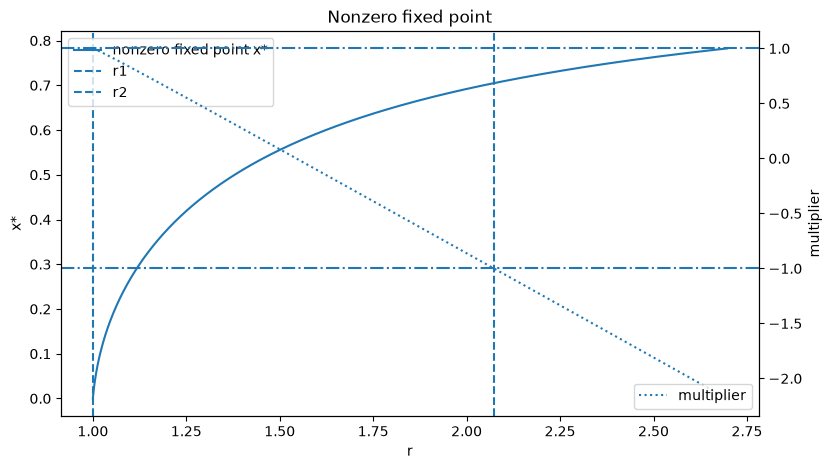

In [7]:
# Cell 6 — Fixed point and multiplier versus r

R_values = np.linspace(max(r1, 1e-6), r_inf, 800)
X_values = np.array([positive_fixed_point(R) for R in R_values])
rho_values = np.array([fixed_multiplier(R) for R in R_values])

fig, ax1 = plt.subplots()
ax1.plot(R_values, X_values, label="nonzero fixed point x*")
ax1.axvline(r1, linestyle="--", label="r1")
ax1.axvline(r2, linestyle="--", label="r2")
ax1.set_xlabel("r")
ax1.set_ylabel("x*")
ax1.set_title("Nonzero fixed point")

ax2 = ax1.twinx()
ax2.plot(R_values, rho_values, linestyle=":", label="multiplier")
ax2.axhline(1, linestyle="-.")
ax2.axhline(-1, linestyle="-.")
ax2.set_ylabel("multiplier")

ax1.legend(loc="upper left")
ax2.legend(loc="lower right")
plt.show()

### Task 3 - Period-2 cycle

A period-2 cycle satisfies \[f(f(x))=x,\] but fixed points must be excluded. The following numerical procedure finds the roots of \(f^{(2)}(x)-x\), removes fixed points, and reports the two cycle points and their multiplier.

In [8]:
# Cell 7 — Find a period-2 cycle

def iterate_map(x0, R, n):
    xval = float(x0)
    for _ in range(n):
        xval = cubic_map(xval, R)
    return xval

def roots_of_iterate(R, n, grid_size=12000):
    xs = np.linspace(0, 1, grid_size + 1)
    vals = np.array([iterate_map(z, R, n) - z for z in xs])
    roots = []

    for i in range(grid_size):
        if vals[i] == 0:
            roots.append(xs[i])
        elif vals[i] * vals[i+1] < 0:
            roots.append(brentq(
                lambda z: iterate_map(z, R, n) - z,
                xs[i], xs[i+1]
            ))

    roots = sorted(roots)
    unique = []
    for z in roots:
        if not unique or abs(z - unique[-1]) > 1e-7:
            unique.append(z)
    return np.array(unique)

def period2_multiplier(a, R):
    b = cubic_map(a, R)
    return cubic_derivative(a, R) * cubic_derivative(b, R)

r_cycle2 = r2 + 0.15
roots2 = roots_of_iterate(r_cycle2, 2)
cycle2 = [z for z in roots2 if abs(cubic_map(z, r_cycle2) - z) > 1e-6]

print(f"Example r = {r_cycle2:.8f}")
print("Period-2 points:")
for z in cycle2:
    print(f"  {z:.10f}")
if cycle2:
    print(f"Cycle-2 multiplier = {period2_multiplier(cycle2[0], r_cycle2):.10f}")

Example r = 2.22306014
Period-2 points:
  0.5615571307
  0.8239682727
Cycle-2 multiplier = -0.1787850500


### Task 4 - Period-3 cycle and period-doubling value \(r_3\)

A period-3 orbit satisfies \[f^{(3)}(x)=x\] while not being a fixed point or a period-2 point. The stability multiplier is \[ho_3=f'(x_1)f'(x_2)f'(x_3).\] The cycle loses stability through period doubling when \(ho_3=-1\).

In [9]:
# Cell 8 — Period-3 cycle and r3

def period3_multiplier(a, R):
    z = a
    product = 1.0
    for _ in range(3):
        product *= cubic_derivative(z, R)
        z = cubic_map(z, R)
    return product

# Search for the first stable period-3 branch.
def period3_candidates(R):
    roots = roots_of_iterate(R, 3, grid_size=7000)
    return [z for z in roots if abs(cubic_map(z, R) - z) > 1e-5]

# A stable period-3 window exists close to the upper part of the
# invariant parameter interval for k=9.
search_R = np.linspace(r_inf*0.94, r_inf*0.999, 80)

candidate_data = []
for R in search_R:
    p3 = period3_candidates(R)
    for z in p3:
        m = period3_multiplier(z, R)
        if abs(m) < 1:
            candidate_data.append((R, z, m))

if candidate_data:
    R0 = candidate_data[0][0]
    z0 = candidate_data[0][1]

    # Follow the branch by selecting the period-3 point with negative multiplier.
    def stable_branch_multiplier(R):
        candidates = period3_candidates(R)
        if not candidates:
            return np.nan
        vals = [(z, period3_multiplier(z, R)) for z in candidates]
        negative = [item for item in vals if item[1] < 0]
        if negative:
            return min(negative, key=lambda item: abs(item[1]))[1]
        return min(vals, key=lambda item: abs(item[1]))[1]

    r3 = brentq(lambda R: stable_branch_multiplier(R) + 1,
                R0, min(r_inf, R0 + 0.08))

    cycle3 = period3_candidates(r3)
    cycle3 = sorted(cycle3, key=lambda z: abs(period3_multiplier(z, r3) + 1))[:3]

    print(f"r3 ≈ {r3:.10f}")
    print(f"Tolerance 0.001*r_infinity = {0.001*r_inf:.10f}")
    print("Representative period-3 points:")
    for z in cycle3:
        print(f"  {z:.10f}")
    if cycle3:
        print(f"Multiplier ≈ {period3_multiplier(cycle3[0], r3):.10f}")
else:
    r3 = np.nan
    print("No period-3 stable branch was detected in the automatic search.")

r3 ≈ 2.5571766857
Tolerance 0.001*r_infinity = 0.0026965225
Representative period-3 points:
  0.9474829477
  0.5584804971
  0.2357467449
Multiplier ≈ -1.0000000000


### Task 5 - Numerical dynamics as the parameter varies

The dynamics are examined by iterating the map after discarding an initial transient. This allows the fixed-point, periodic and more complicated regimes to be observed directly.

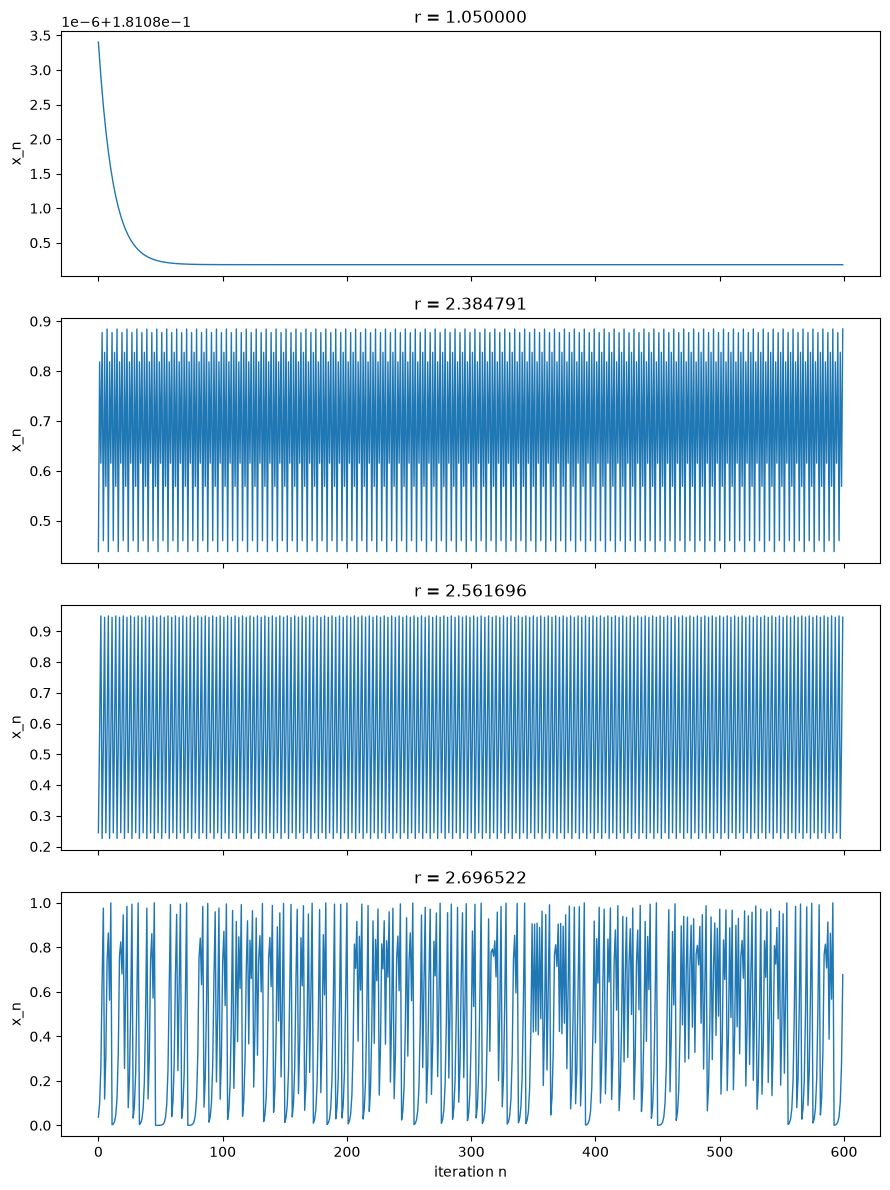

In [10]:
# Cell 9 — Representative time series

def trajectory(R, x0=0.2, n=600, discard=100):
    values = []
    z = x0
    for i in range(n + discard):
        z = cubic_map(z, R)
        if i >= discard:
            values.append(z)
    return np.array(values)

representative_R = [
    max(1.05, r1 + 0.05),
    (r2 + r_inf)/2,
    r_inf*0.95,
    r_inf
]

fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

for ax, R in zip(axes, representative_R):
    y = trajectory(R)
    ax.plot(np.arange(len(y)), y, linewidth=1)
    ax.set_ylabel("x_n")
    ax.set_title(f"r = {R:.6f}")

axes[-1].set_xlabel("iteration n")
plt.tight_layout()
plt.show()

### Task 6 - Bifurcation diagram on `[0.95 r2, r∞]`

The supplied Maple reference constructs a bifurcation diagram by varying the parameter, discarding transient iterations, and plotting the remaining iterates against the parameter.

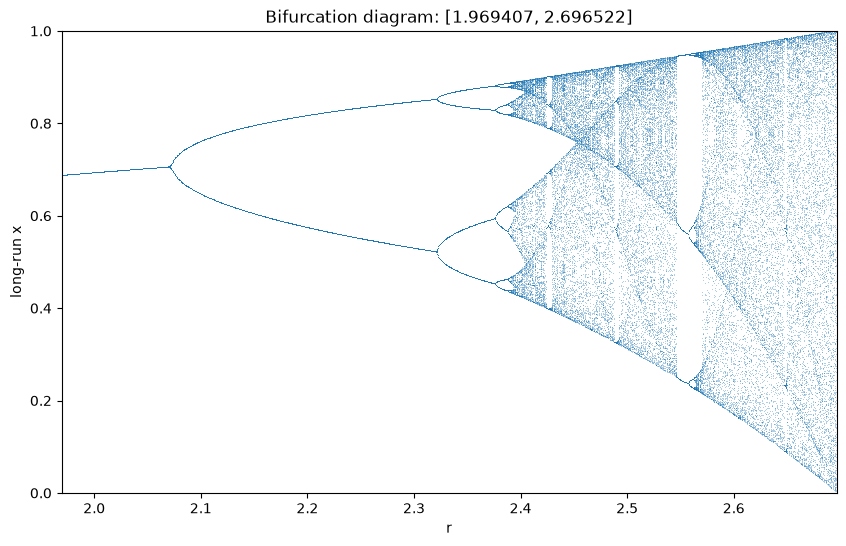

In [11]:
# Cell 10 — Bifurcation diagram

def bifurcation_data(rbeg, rend, n_parameters=1200, transient=500, keep=100):
    R_values = np.linspace(rbeg, rend, n_parameters)
    R_plot = []
    X_plot = []

    for R in R_values:
        z = 1 - 1/R if R != 0 else 0.2

        for _ in range(transient):
            z = cubic_map(z, R)

        for _ in range(keep):
            z = cubic_map(z, R)
            R_plot.append(R)
            X_plot.append(z)

    return np.array(R_plot), np.array(X_plot)

rbeg = max(0.95*r2, 1e-6)
R_plot, X_plot = bifurcation_data(rbeg, r_inf)

plt.figure(figsize=(10, 6))
plt.plot(R_plot, X_plot, ",", alpha=0.35)
plt.xlabel("r")
plt.ylabel("long-run x")
plt.title(f"Bifurcation diagram: [{rbeg:.6f}, {r_inf:.6f}]")
plt.xlim(rbeg, r_inf)
plt.ylim(0, 1)
plt.show()

### Task 7 - Iteration-density distributions

The supplied Maple reference estimates iteration density by dividing `[0,1]` into bins and counting the long-run iterates. It also gives the invariant density for the classical logistic map at \(r=4\),\[ho(x)=rac{1}{\pi\sqrt{x(1-x)}}.\]

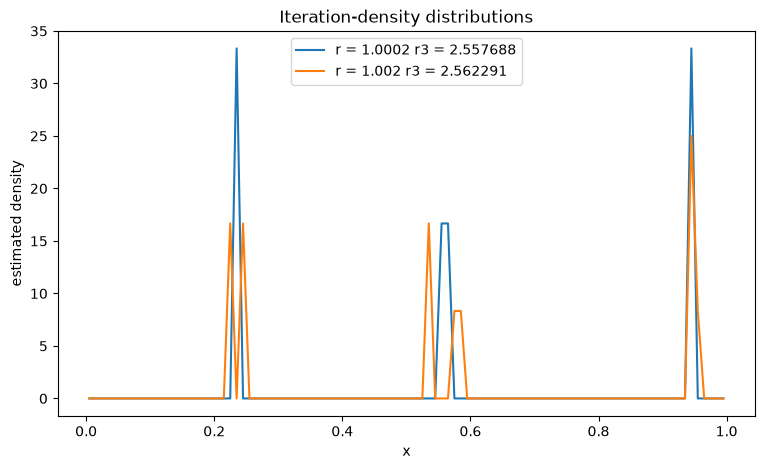

In [12]:
# Cell 11 — Iteration-density estimator

def iteration_density(R, x0=0.1, n=200000, bins=100, discard=1000):
    z = float(x0)

    for _ in range(discard):
        z = cubic_map(z, R)

    values = np.empty(n)
    for i in range(n):
        z = cubic_map(z, R)
        values[i] = z

    density, edges = np.histogram(
        values, bins=bins, range=(0, 1), density=True
    )
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, density

# The assignment requests 1.0002*r3 and 1.002*r3.
if np.isfinite(r3):
    R_a = 1.0002*r3
    R_b = 1.002*r3

    centers_a, density_a = iteration_density(R_a)
    centers_b, density_b = iteration_density(R_b)

    plt.figure(figsize=(9, 5))
    plt.plot(centers_a, density_a, label=f"r = 1.0002 r3 = {R_a:.6f}")
    plt.plot(centers_b, density_b, label=f"r = 1.002 r3 = {R_b:.6f}")
    plt.xlabel("x")
    plt.ylabel("estimated density")
    plt.title("Iteration-density distributions")
    plt.legend()
    plt.show()
else:
    print("Run the period-3 calculation first to obtain r3.")

### Lab 1 - Summary

For the chosen student number \(k=9\), the cubic mapping was analysed through its invariant parameter interval, nonzero fixed point, multiplier, periodic cycles, direct iteration, bifurcation diagram and iteration-density estimates.

The main numerical transition points are computed automatically by the notebook rather than copied from a fixed example. This is important because the individual parameter \(k\) changes the map.

# Lab 2 - Prey-Predator Dynamics

The laboratory defines \[\dot{x}=a(t)f(x)x-xy,\qquad\dot{y}=-b(t)y+xy,\] with \[a(t)=1+lpha\sin(\omega t),\qquadb(t)=\gamma+eta\sin(\omega t),\] and \[f(x)=(1-c+cx)(1-x),\qquad c=rac{k}{25}.\]

In [13]:
# Cell 12 — Lab 2 parameters and model

c = k/25
omega = k

def prey_function(x):
    return (1 - c + c*x)*(1 - x)

def predator_prey_rhs(t, state, gamma, alpha=0.0, beta=0.0):
    x, y = state
    a = 1 + alpha*np.sin(omega*t)
    b = gamma + beta*np.sin(omega*t)
    dx = a*prey_function(x)*x - x*y
    dy = -b*y + x*y
    return [dx, dy]

print(f"k = {k}")
print(f"c = {c:.6f}")
print(f"omega = {omega}")

k = 9
c = 0.360000
omega = 9


## Lab 2, Task 1 - Autonomous equilibria and stability

The equilibria are obtained from \(\dot{x}=0,\dot{y}=0\). The principal equilibria are \[E_0=(0,0),\qquad E_1=(1,0),\] and, when it is biologically meaningful, \[E_*=(\gamma,f(\gamma)).\]

In [14]:
# Cell 13 — Equilibria and Jacobian

def lab2_jacobian(x, y, gamma):
    eps = 1e-6
    # Analytical Jacobian for the autonomous system.
    # dx = x*f(x) - x*y
    # dy = y*(x-gamma)
    fval = prey_function(x)
    fp = c*(1-x) - (1-c+c*x)

    J11 = fval + x*fp - y
    J12 = -x
    J21 = y
    J22 = x - gamma
    return np.array([[J11, J12], [J21, J22]], dtype=float)

def equilibrium_points(gamma):
    eq = [(0.0, 0.0), (1.0, 0.0)]
    y_star = prey_function(gamma)
    if 0 < gamma < 1 and y_star > 0:
        eq.append((gamma, y_star))
    return eq

def classify_equilibrium(point, gamma):
    J = lab2_jacobian(point[0], point[1], gamma)
    eig = np.linalg.eigvals(J)
    real_parts = np.real(eig)

    if np.all(real_parts < 0):
        classification = "stable"
    elif np.all(real_parts > 0):
        classification = "unstable"
    elif np.any(real_parts < 0) and np.any(real_parts > 0):
        classification = "saddle"
    else:
        classification = "non-hyperbolic / boundary case"

    return eig, classification

for gamma in [0.2, 0.6, 1.2]:
    print(f"\ngamma = {gamma}")
    for eq in equilibrium_points(gamma):
        eig, cls = classify_equilibrium(eq, gamma)
        print(f"  E = {eq}, eigenvalues = {eig}, classification = {cls}")


gamma = 0.2
  E = (0.0, 0.0), eigenvalues = [ 0.64 -0.2 ], classification = saddle
  E = (1.0, 0.0), eigenvalues = [-1.   0.8], classification = saddle
  E = (0.2, 0.5696), eigenvalues = [-0.0424+0.334847j -0.0424-0.334847j], classification = stable

gamma = 0.6
  E = (0.0, 0.0), eigenvalues = [ 0.64 -0.6 ], classification = saddle
  E = (1.0, 0.0), eigenvalues = [-1.   0.4], classification = saddle
  E = (0.6, 0.34240000000000004), eigenvalues = [-0.2136+0.399769j -0.2136-0.399769j], classification = stable

gamma = 1.2
  E = (0.0, 0.0), eigenvalues = [ 0.64 -1.2 ], classification = saddle
  E = (1.0, 0.0), eigenvalues = [-1.  -0.2], classification = stable


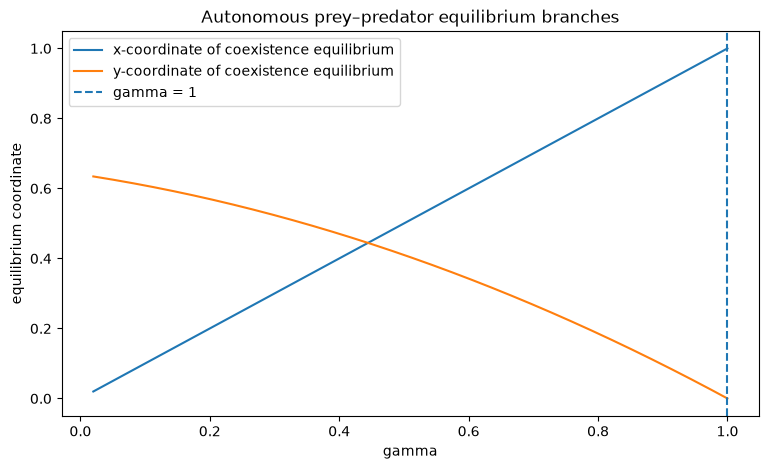

In [15]:
# Cell 14 — Bifurcation/stability diagram versus gamma

gamma_values = np.linspace(0.02, 1.30, 500)
coexist_y = np.array([
    prey_function(g) if 0 < g < 1 else np.nan
    for g in gamma_values
])

plt.figure(figsize=(9, 5))
plt.plot(gamma_values, np.where(gamma_values < 1, gamma_values, np.nan),
         label="x-coordinate of coexistence equilibrium")
plt.plot(gamma_values, coexist_y,
         label="y-coordinate of coexistence equilibrium")
plt.axvline(1, linestyle="--", label="gamma = 1")
plt.xlabel("gamma")
plt.ylabel("equilibrium coordinate")
plt.title("Autonomous prey–predator equilibrium branches")
plt.legend()
plt.show()

## Lab 2, Task 2 - Non-autonomous transitions

For \(k=9\), which is odd, the assignment specifies \[lpha=0,\qquad \omega=9,\] and the parameter \(eta\) is varied. The following simulations show how periodic forcing changes the trajectory for representative values of \(\gamma\).

In [16]:
# Cell 15 — Non-autonomous simulation utilities

def simulate_lab2(gamma, beta, alpha=0.0, x0=0.7, y0=0.2,
                  periods=300, points_per_period=80):
    T = 2*np.pi/omega
    t_eval = np.linspace(
        0, periods*T, periods*points_per_period + 1
    )

    sol = solve_ivp(
        lambda t, z: predator_prey_rhs(
            t, z, gamma=gamma, alpha=alpha, beta=beta
        ),
        [0, periods*T],
        [x0, y0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
        max_step=T/30
    )
    return sol

# Representative gamma values.
gamma_stable_prey = 1.20
gamma_stable_coexistence = 0.60
gamma_low = 0.20

print("Representative gamma values:")
print(gamma_stable_prey, gamma_stable_coexistence, gamma_low)

Representative gamma values:
1.2 0.6 0.2


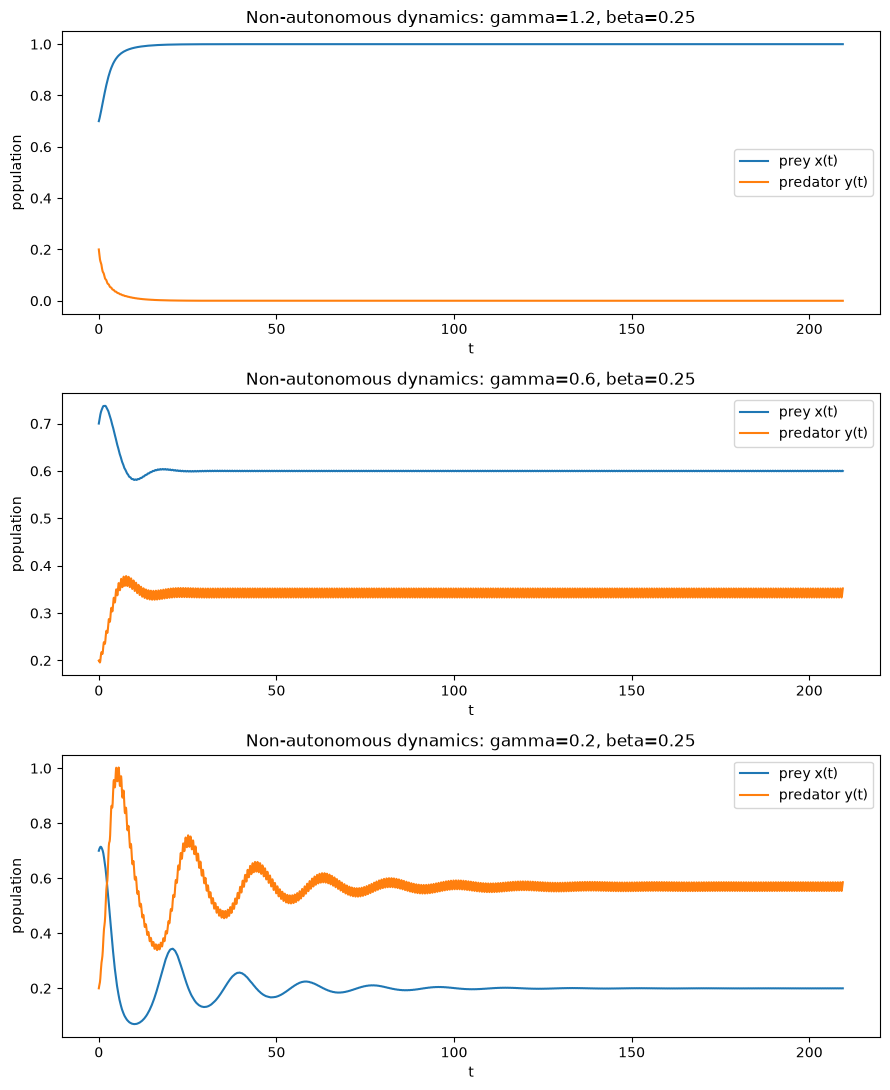

In [17]:
# Cell 16 — Forced trajectories for representative gamma values

beta_demo = 0.25

fig, axes = plt.subplots(3, 1, figsize=(9, 11))

for ax, gamma in zip(
    axes,
    [gamma_stable_prey, gamma_stable_coexistence, gamma_low]
):
    sol = simulate_lab2(gamma, beta_demo)
    ax.plot(sol.t, sol.y[0], label="prey x(t)")
    ax.plot(sol.t, sol.y[1], label="predator y(t)")
    ax.set_title(f"Non-autonomous dynamics: gamma={gamma}, beta={beta_demo}")
    ax.set_xlabel("t")
    ax.set_ylabel("population")
    ax.legend()

plt.tight_layout()
plt.show()

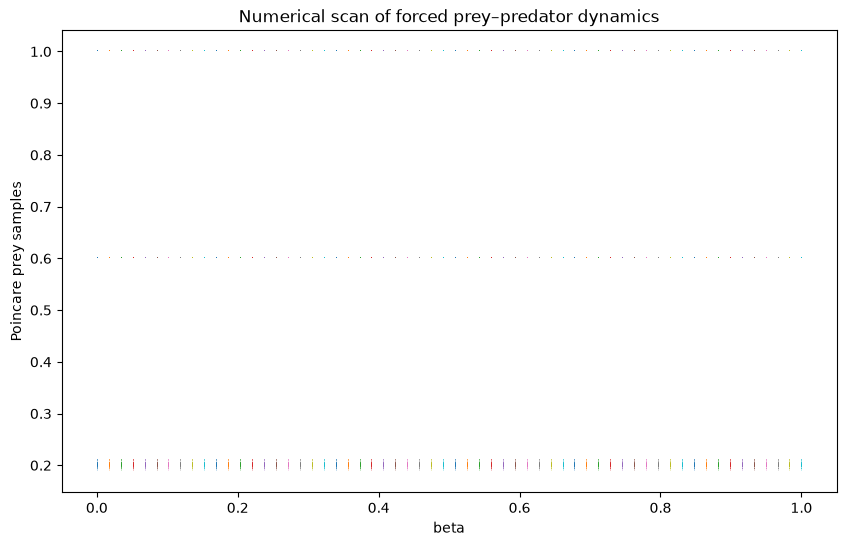

In [18]:
# Cell 17 — Scan beta and estimate oscillation complexity

def poincare_samples(gamma, beta, periods=250, discard=100):
    sol = simulate_lab2(gamma, beta, periods=periods)
    T = 2*np.pi/omega

    # Sample close to integer forcing periods.
    t_samples = np.arange(discard, periods+1)*T
    x_samples = np.interp(t_samples, sol.t, sol.y[0])
    return x_samples

beta_values = np.linspace(0, 1.0, 60)

plt.figure(figsize=(10, 6))

for gamma in [gamma_stable_prey, gamma_stable_coexistence, gamma_low]:
    for beta in beta_values:
        samples = poincare_samples(gamma, beta)
        plt.plot(
            np.full_like(samples, beta),
            samples,
            ",",
            alpha=0.25
        )

plt.xlabel("beta")
plt.ylabel("Poincare prey samples")
plt.title("Numerical scan of forced prey–predator dynamics")
plt.show()

**Interpretation of Lab 2.**  
The autonomous analysis identifies the equilibrium branches and their local stability. The forced simulations then show how periodic forcing can create sustained oscillations. The Poincaré diagram is used as a numerical diagnostic: a small finite set of repeated points is consistent with periodic behaviour, while a complicated non-repeating cloud is a numerical indication of more complex dynamics. A numerical diagnostic should not by itself be treated as a rigorous proof of chaos.

# Lab 3 - Dynamics of Two Competing Fish Species

The laboratory defines \[\dot{x}=x(1-x-y)-lpha x,\] \[\dot{y}=rac{1}{k}y(1-x-y)-eta y.\]

In [19]:
# Cell 18 — Lab 3 model

def fish_rhs(t, state, alpha, beta):
    x, y = state
    dx = x*(1 - x - y) - alpha*x
    dy = (1/k)*y*(1 - x - y) - beta*y
    return [dx, dy]

print(f"Competition model uses k = {k}")

Competition model uses k = 9


## Lab 3, Task 1 - Equilibria and stability

The equilibrium equations factor as \[x(1-lpha-x-y)=0,\] \[y\left(rac{1-x-y}{k}-etaight)=0.\]

In [20]:
# Cell 19 — Lab 3 equilibrium and Jacobian analysis

def fish_jacobian(x, y, alpha, beta):
    return np.array([
        [1 - alpha - 2*x - y, -x],
        [-y/k, (1/k)*(1 - x - 2*y) - beta]
    ], dtype=float)

def fish_equilibria(alpha, beta, tol=1e-10):
    eq = [(0.0, 0.0)]

    if 1-alpha >= -tol:
        eq.append((max(0.0, 1-alpha), 0.0))

    if 1-k*beta >= -tol:
        eq.append((0.0, max(0.0, 1-k*beta)))

    if abs(alpha-k*beta) < tol and 1-alpha >= 0:
        # Interior points form a continuum on x+y=1-alpha.
        eq.append(("continuum", 1-alpha))

    return eq

def classify_fish_point(x, y, alpha, beta):
    J = fish_jacobian(x, y, alpha, beta)
    eig = np.linalg.eigvals(J)
    return eig

# Example parameter values
alpha_demo = 0.2
beta_demo = 0.04

print("Equilibria for the demonstration parameters:")
print(fish_equilibria(alpha_demo, beta_demo))

for eq in fish_equilibria(alpha_demo, beta_demo):
    if isinstance(eq[0], str):
        continue
    print(f"E={eq}, eigenvalues={classify_fish_point(eq[0], eq[1], alpha_demo, beta_demo)}")

Equilibria for the demonstration parameters:
[(0.0, 0.0), (0.8, 0.0), (0.0, 0.64)]
E=(0.0, 0.0), eigenvalues=[0.8      0.071111]
E=(0.8, 0.0), eigenvalues=[-0.8      -0.017778]
E=(0.0, 0.64), eigenvalues=[-0.071111  0.16    ]


## Lab 3, Task 2 - Computer simulations

The phase-plane simulations below illustrate three qualitatively different situations:

1. species \(x\) persists while \(y\) declines;
2. species \(y\) persists while \(x\) declines;
3. parameters are close to the coexistence boundary.

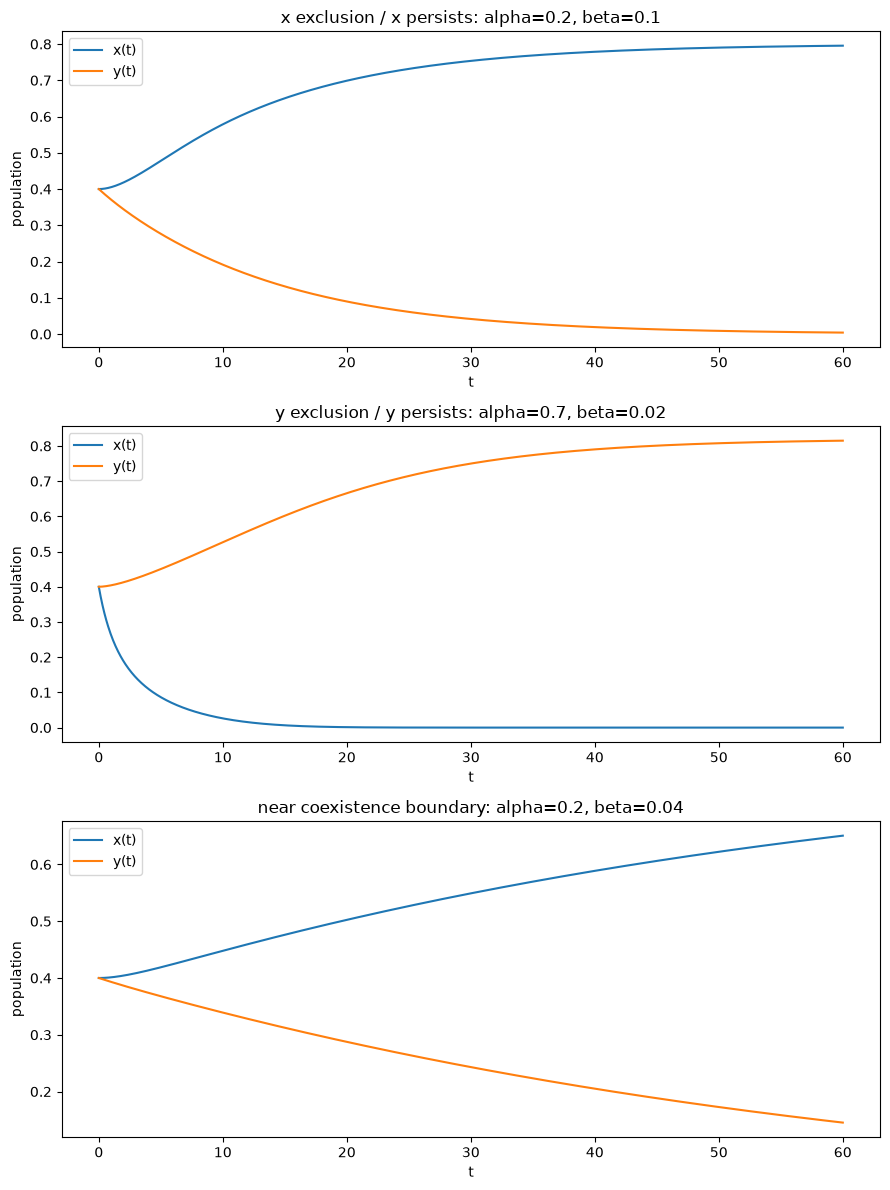

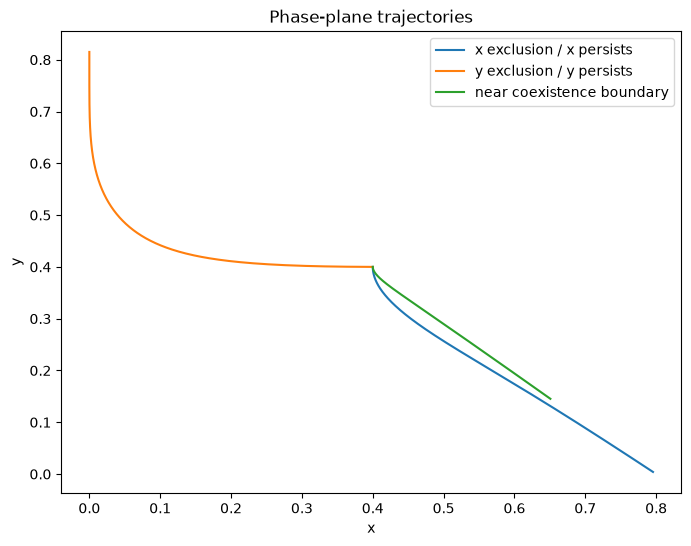

In [21]:
# Cell 20 — Phase-plane and time-series simulations

def simulate_fish(alpha, beta, initial=(0.4, 0.4), t_end=60):
    t_eval = np.linspace(0, t_end, 1200)
    sol = solve_ivp(
        lambda t, z: fish_rhs(t, z, alpha, beta),
        [0, t_end],
        initial,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11
    )
    return sol

cases = [
    (0.20, 0.10, "x exclusion / x persists"),
    (0.70, 0.02, "y exclusion / y persists"),
    (0.20, 0.04, "near coexistence boundary")
]

fig, axes = plt.subplots(3, 1, figsize=(9, 12))

for ax, (alpha, beta, title) in zip(axes, cases):
    sol = simulate_fish(alpha, beta)
    ax.plot(sol.t, sol.y[0], label="x(t)")
    ax.plot(sol.t, sol.y[1], label="y(t)")
    ax.set_title(f"{title}: alpha={alpha}, beta={beta}")
    ax.set_xlabel("t")
    ax.set_ylabel("population")
    ax.legend()

plt.tight_layout()
plt.show()

# Phase portrait for the same cases
plt.figure(figsize=(8, 6))
for alpha, beta, title in cases:
    sol = simulate_fish(alpha, beta)
    plt.plot(sol.y[0], sol.y[1], label=title)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Phase-plane trajectories")
plt.legend()
plt.show()

## Lab 3, Task 3 - Conditions for exclusion

From the linearization:

### Species x excludes species y

At \(E_x=(1-lpha,0)\), the invasion eigenvalue for species \(y\) is \[rac{lpha}{k}-eta.\] Therefore \(E_x\) is locally stable when \[0<lpha<1,\qquad eta>rac{lpha}{k}.\]

### Species y excludes species x

At \(E_y=(0,1-keta)\), the invasion eigenvalue for species \(x\) is \[keta-lpha.\] Thus \(E_y\) is locally stable when \[0<eta<rac1k,\qquad lpha>keta.\]

### Boundary between the two regimes

The equality \[oxed{lpha=keta}\] is the competition boundary. At this boundary the model has a continuum of equilibria satisfying \[x+y=1-lpha.\]

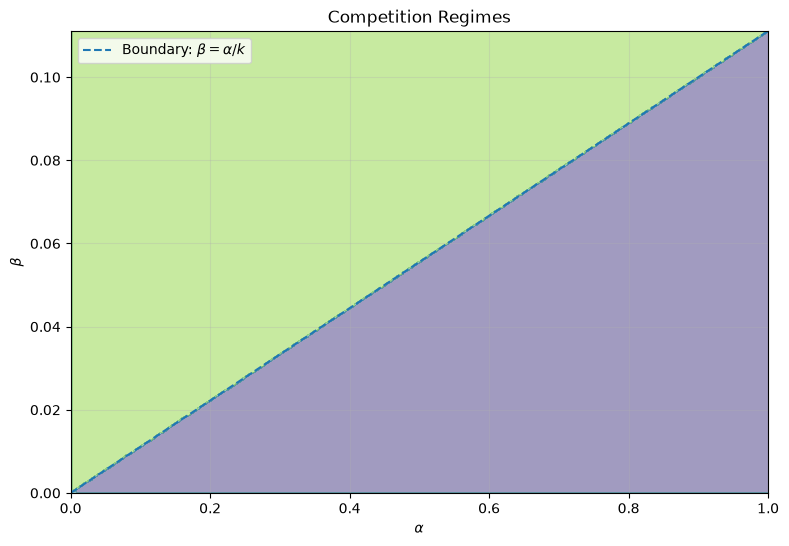

In [24]:
# Cell 21 — Numerical exclusion map in the (alpha, beta) plane

alpha_values = np.linspace(0, 1, 250)
beta_values = np.linspace(0, 1/k, 250)

A, B = np.meshgrid(alpha_values, beta_values)

# Regimes:
#  1  -> x excludes y
# -1  -> y excludes x
#  0  -> boundary/other
regime = np.zeros_like(A)

regime[(A > 0) & (A < 1) & (B > A/k)] = 1
regime[(B > 0) & (B < 1/k) & (A > k * B)] = -1

plt.figure(figsize=(9, 6))

plt.contourf(
    A,
    B,
    regime,
    levels=[-1.5, -0.5, 0.5, 1.5],
    alpha=0.5
)

# Boundary: beta = alpha / k
plt.plot(
    alpha_values,
    alpha_values / k,
    linestyle="--",
    label=r"Boundary: $\beta=\alpha/k$"
)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.title("Competition Regimes")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion

I implemented the three Mathematical Models in Biology laboratories computationally.

- **Lab 1:** the cubic discrete map was analysed using fixed points, multipliers, periodic cycles, direct iteration, a bifurcation diagram and iteration-density estimates.
- **Lab 2:** the prey–predator model was examined through equilibrium calculations, eigenvalue stability analysis, numerical integration and forced-response diagnostics.
- **Lab 3:** the two-species competition model was analysed through equilibria, Jacobian stability, numerical simulations and explicit exclusion conditions.